**Customer Churn Prediction for a Telecom Company using Machine Learning**

**Importing Data**

In [69]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("telco.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Couldn't find telco.csv. Put it in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

# Display first 5 rows
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [70]:
# Check dataset size
rows, cols = df.shape

print(f"Number of rows (customers): {rows}")
print(f"Number of columns (features): {cols}")

Number of rows (customers): 7043
Number of columns (features): 50


In [71]:
# Display column names 
pd.DataFrame(df.columns, columns=["Column Names"])

,Column Names
0,Customer ID
1,Gender
2,Age
3,Under 30
4,Senior Citizen
5,Married
6,Dependents
7,Number of Dependents
8,Country
9,State


In [72]:
# Check data types of each column
df.dtypes.to_frame(name="Data Type")

,Data Type
Customer ID,object
Gender,object
Age,int64
Under 30,object
Senior Citizen,object
Married,object
Dependents,object
Number of Dependents,int64
Country,object
State,object


***The table below summarizes the distribution of numeric features and helps identify scale differences and potential outliers.***

In [73]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Zip Code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
Population,7043.0,22139.603294,21152.392837,11.000000,2344.000000,17554.000000,36125.000000,105285.000000
Number of Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,7043.0,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
Avg Monthly GB Download,7043.0,20.515405,20.418940,0.000000,3.000000,17.000000,27.000000,85.000000


In [74]:
# Check missing values per column (only show columns with missing data)
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

Churn Category    5174
Churn Reason      5174
Offer             3877
Internet Type     1526
dtype: int64

**Data Cleaning**

In [75]:
# Handle missing values

# Fill missing 'Offer' with 'No Offer'
df['Offer'] = df['Offer'].fillna('No Offer')

# Fill missing 'Internet Type' with 'Unknown'
df['Internet Type'] = df['Internet Type'].fillna('Unknown')

# Drop 'Churn Category' and 'Churn Reason' columns
df = df.drop(['Churn Category', 'Churn Reason'], axis=1)

# Double-check to make sure missing values are handled
df.isnull().sum()

Customer ID                          0
Gender                               0
Age                                  0
Under 30                             0
Senior Citizen                       0
Married                              0
Dependents                           0
Number of Dependents                 0
Country                              0
State                                0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Population                           0
Quarter                              0
Referred a Friend                    0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download  

In [76]:
# Summary for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Customer ID
Customer ID
8779-QRDMV    1
9817-APLHW    1
5447-VYTKW    1
8871-JLMHM    1
7029-IJEJK    1
             ..
5493-SDRDQ    1
9249-FXSCK    1
3063-QFSZL    1
8364-TRMMK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

Column: Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: Under 30
Under 30
No     5642
Yes    1401
Name: count, dtype: int64

Column: Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Column: Married
Married
No     3641
Yes    3402
Name: count, dtype: int64

Column: Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Column: Country
Country
United States    7043
Name: count, dtype: int64

Column: State
State
California    7043
Name: count, dtype: int64

Column: City
City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Jacumba               2
South Lake Tahoe      2


In [77]:
# Calculate churn rate
churned = df[df['Churn Label'] == 'Yes'].shape[0]
total_customers = df.shape[0]
churn_rate = (churned / total_customers) * 100

print(f"Churn Rate: {churn_rate:.2f}%")


Churn Rate: 26.54%


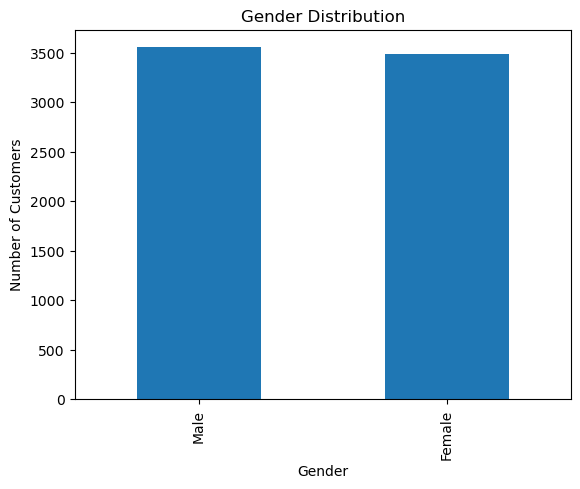

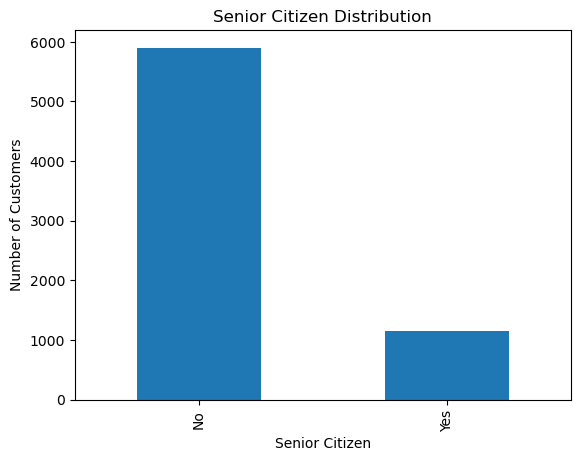

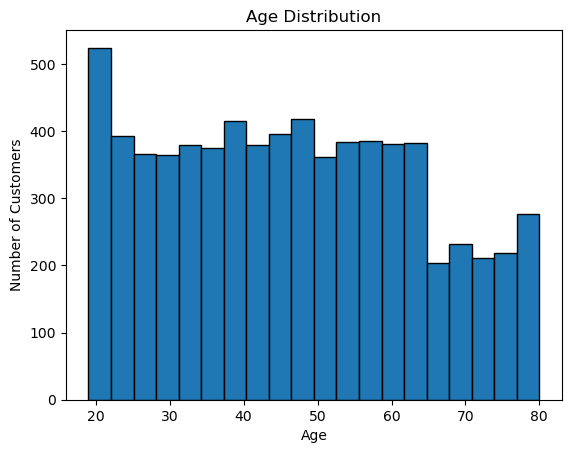

In [78]:
import matplotlib.pyplot as plt

# Gender distribution
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# Senior Citizen distribution
df["Senior Citizen"].value_counts().plot(kind="bar")
plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

# Age distribution
plt.hist(df["Age"], bins=20, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

***These visualizations help understand the demographic composition of customers and identify patterns that may influence churn behavior.***

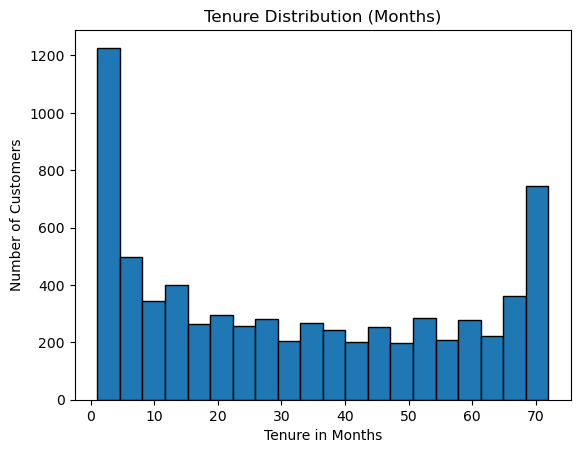

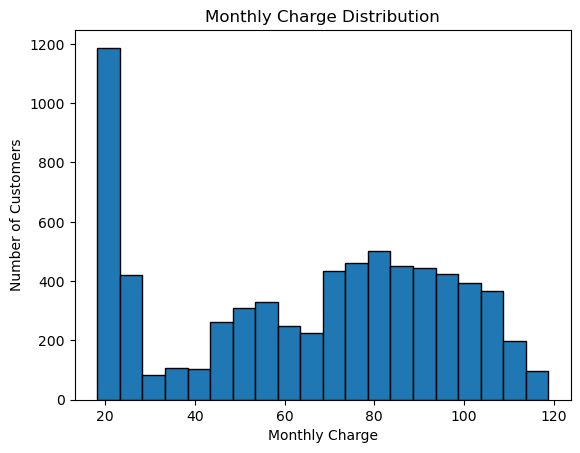

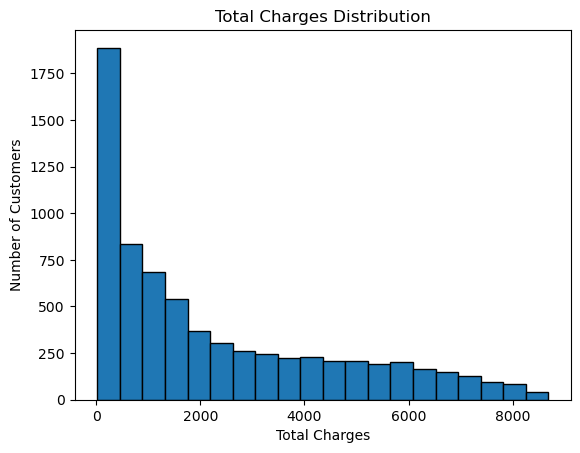

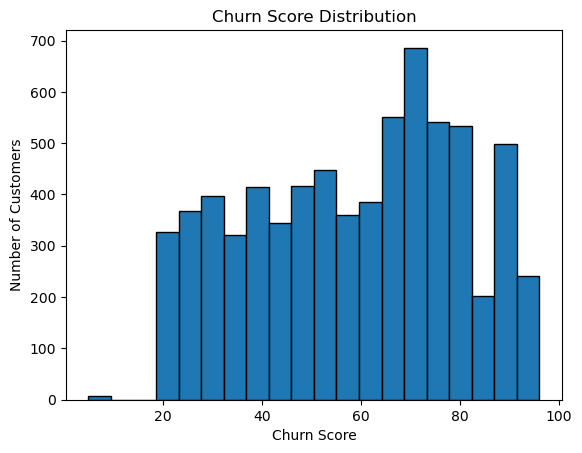

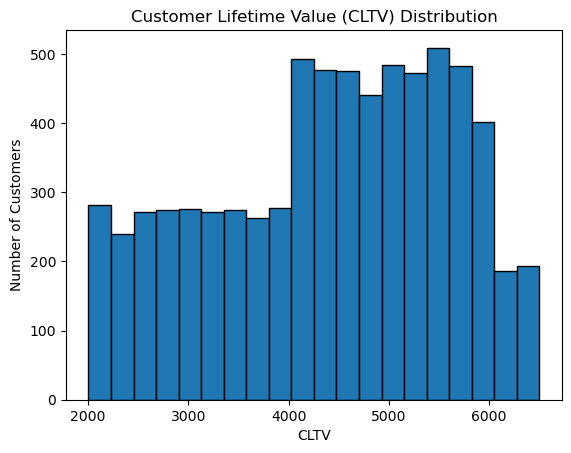

In [79]:
# Tenure distribution
plt.hist(df["Tenure in Months"], bins=20, edgecolor="black")
plt.title("Tenure Distribution (Months)")
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")
plt.show()

# Monthly Charge distribution
plt.hist(df["Monthly Charge"], bins=20, edgecolor="black")
plt.title("Monthly Charge Distribution")
plt.xlabel("Monthly Charge")
plt.ylabel("Number of Customers")
plt.show()

# Total Charges distribution
plt.hist(df["Total Charges"], bins=20, edgecolor="black")
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

# Churn Score distribution
plt.hist(df["Churn Score"], bins=20, edgecolor="black")
plt.title("Churn Score Distribution")
plt.xlabel("Churn Score")
plt.ylabel("Number of Customers")
plt.show()

# CLTV distribution
plt.hist(df["CLTV"], bins=20, edgecolor="black")
plt.title("Customer Lifetime Value (CLTV) Distribution")
plt.xlabel("CLTV")
plt.ylabel("Number of Customers")
plt.show()


***These distributions help understand customer behavior, spending patterns, and tenure, which are important factors in predicting churn.***

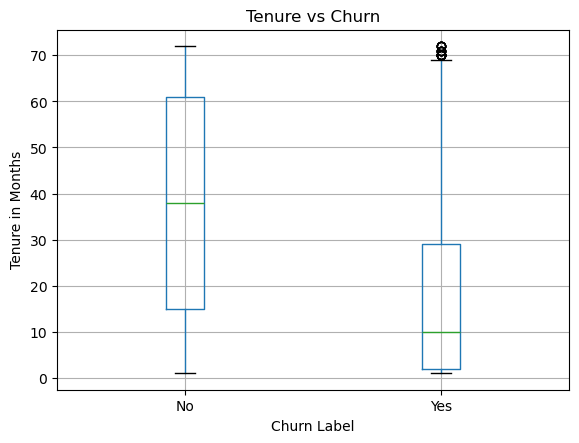

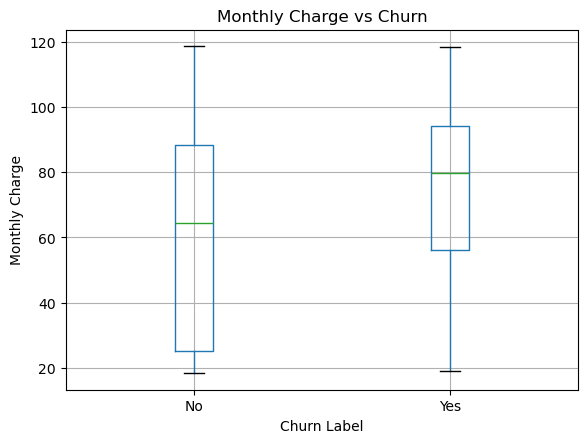

In [80]:
# Compare tenure between churned and non-churned customers
df.boxplot(column="Tenure in Months", by="Churn Label")
plt.title("Tenure vs Churn")
plt.suptitle("")  # removes automatic title
plt.xlabel("Churn Label")
plt.ylabel("Tenure in Months")
plt.show()

# Compare monthly charges between churned and non-churned customers
df.boxplot(column="Monthly Charge", by="Churn Label")
plt.title("Monthly Charge vs Churn")
plt.suptitle("")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charge")
plt.show()

***These boxplots compare key numerical features between churned and non-churned customers to identify behavioral differences associated with churn.***

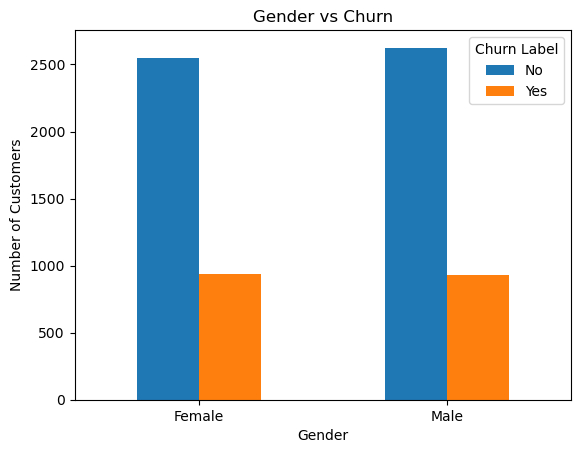

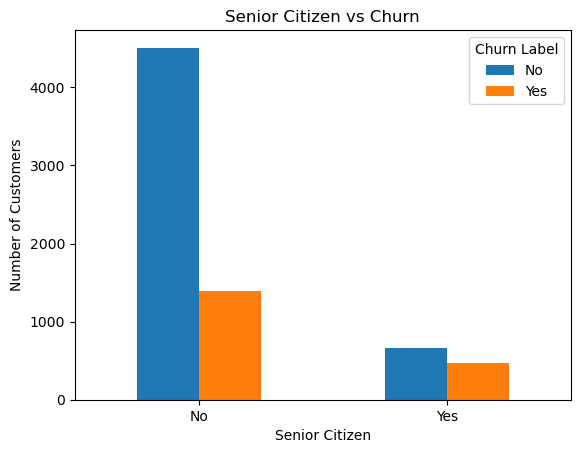

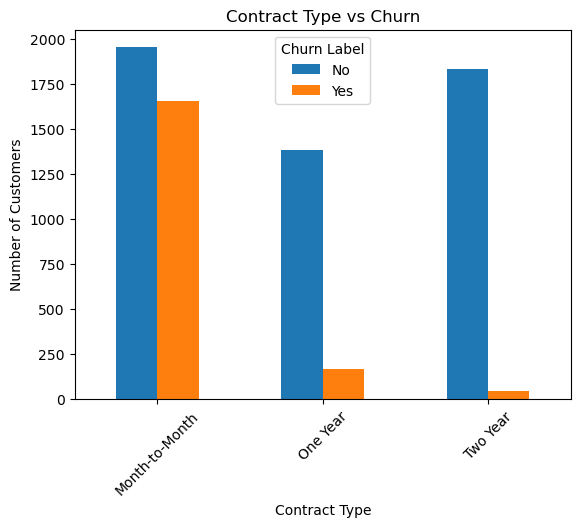

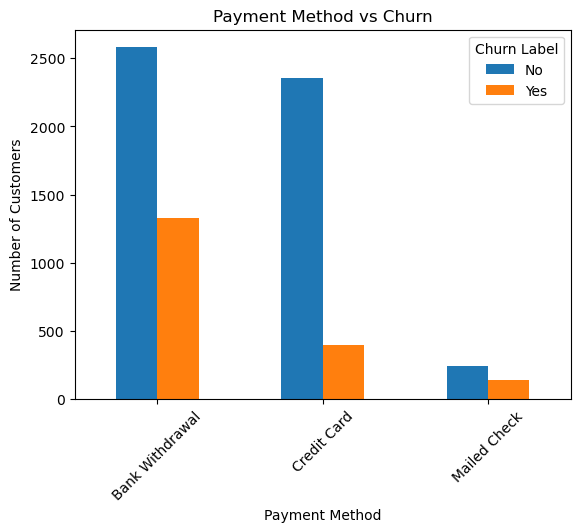

In [81]:
# Gender vs Churn
pd.crosstab(df["Gender"], df["Churn Label"]).plot(kind="bar")
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# Senior Citizen vs Churn
pd.crosstab(df["Senior Citizen"], df["Churn Label"]).plot(kind="bar")
plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# Contract vs Churn
pd.crosstab(df["Contract"], df["Churn Label"]).plot(kind="bar")
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# Payment Method vs Churn
pd.crosstab(df["Payment Method"], df["Churn Label"]).plot(kind="bar")
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


***These plots compare categorical customer attributes with churn status to identify segments that are more likely to churn.***

In [82]:
# Correlation matrix for key numerical features
numeric_features = [
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "Total Revenue",
    "Churn Score",
    "CLTV"
]

corr_matrix = df[numeric_features].corr()
corr_matrix

,Tenure in Months,Monthly Charge,Total Charges,Total Revenue,Churn Score,CLTV
Tenure in Months,1.000000,0.247582,0.826074,0.853146,-0.224982,0.396292
Monthly Charge,0.247582,1.000000,0.651236,0.588887,0.132115,0.098693
Total Charges,0.826074,0.651236,1.000000,0.972212,-0.123961,0.341947
Total Revenue,0.853146,0.588887,0.972212,1.000000,-0.138072,0.354198
Churn Score,-0.224982,0.132115,-0.123961,-0.138072,1.000000,-0.079232
CLTV,0.396292,0.098693,0.341947,0.354198,-0.079232,1.000000


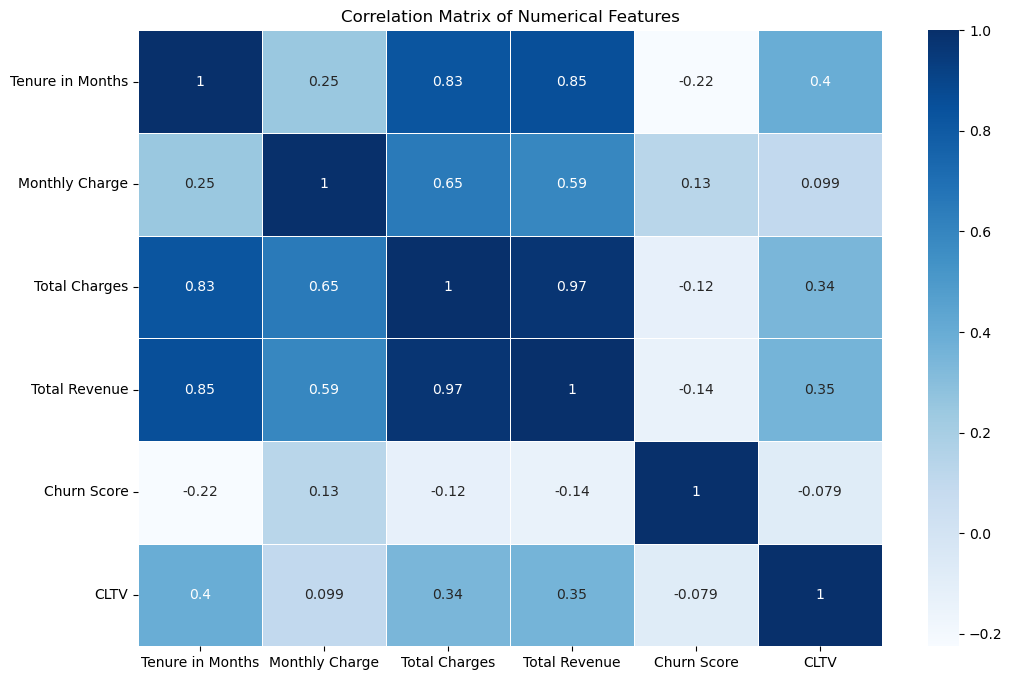

In [83]:
import seaborn as sns

# Correlation matrix for key numerical features
plt.figure(figsize=(12, 8))
corr_matrix = df[['Tenure in Months', 'Monthly Charge', 'Total Charges', 'Total Revenue', 'Churn Score', 'CLTV']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


**Feature Engineering**

In [84]:
df_ml = df.copy()

In [85]:
# drop leakage / ID-type columns
df_ml = df_ml.drop(
    columns=[
        'Customer ID', 'Country', 'State', 'Quarter',
        'Customer Status', 'Churn Score', 'Satisfaction Score'
    ],
    errors='ignore'
)

In [86]:
yes_no_cols = [
    'Under 30', 'Senior Citizen', 'Married', 'Dependents',
    'Referred a Friend', 'Phone Service', 'Multiple Lines',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Paperless Billing',
    'Churn Label'
]

for col in yes_no_cols:
    print(col, df_ml[col].unique())

Under 30 ['No' 'Yes']
Senior Citizen ['Yes' 'No']
Married ['No' 'Yes']
Dependents ['No' 'Yes']
Referred a Friend ['No' 'Yes']
Phone Service ['No' 'Yes']
Multiple Lines ['No' 'Yes']
Online Security ['No' 'Yes']
Online Backup ['No' 'Yes']
Device Protection Plan ['Yes' 'No']
Premium Tech Support ['No' 'Yes']
Streaming TV ['No' 'Yes']
Streaming Movies ['Yes' 'No']
Streaming Music ['No' 'Yes']
Unlimited Data ['No' 'Yes']
Paperless Billing ['Yes' 'No']
Churn Label ['Yes' 'No']


In [87]:
# List of Yes/No columns to convert into 1/0

yes_no_cols = [
    'Under 30', 'Senior Citizen', 'Married', 'Dependents',
    'Referred a Friend', 'Phone Service', 'Multiple Lines',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Paperless Billing',
    'Churn Label'
]

# Convert Yes/No to 1/0
for col in yes_no_cols:
    df_ml[col] = df_ml[col].replace({'Yes': 1, 'No': 0})


C:\Users\krupali patel\AppData\Local\Temp\ipykernel_13124\1055416668.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ml[col] = df_ml[col].replace({'Yes': 1, 'No': 0})


In [88]:
# Double-check conversion
for col in yes_no_cols:
    print(col, df_ml[col].unique())

Under 30 [0 1]
Senior Citizen [1 0]
Married [0 1]
Dependents [0 1]
Referred a Friend [0 1]
Phone Service [0 1]
Multiple Lines [0 1]
Online Security [0 1]
Online Backup [0 1]
Device Protection Plan [1 0]
Premium Tech Support [0 1]
Streaming TV [0 1]
Streaming Movies [1 0]
Streaming Music [0 1]
Unlimited Data [0 1]
Paperless Billing [1 0]
Churn Label [1 0]


In [89]:
# check remaining non-numeric columns
df_ml.select_dtypes(include='object').columns

Index(['Gender', 'City', 'Offer', 'Internet Service', 'Internet Type',
       'Contract', 'Payment Method'],
      dtype='object')

In [90]:
# get categorical columns
cat_cols = df_ml.select_dtypes(include='object').columns

# convert categories into dummy variables
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

In [91]:
# confirm all columns are numeric now
df_ml.dtypes


Age                            int64
Under 30                       int64
Senior Citizen                 int64
Married                        int64
Dependents                     int64
                               ...  
Internet Type_Unknown           bool
Contract_One Year               bool
Contract_Two Year               bool
Payment Method_Credit Card      bool
Payment Method_Mailed Check     bool
Length: 1153, dtype: object

In [92]:
# convert boolean columns (True/False) into 1/0
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

In [93]:
df_ml.dtypes

Age                            int64
Under 30                       int64
Senior Citizen                 int64
Married                        int64
Dependents                     int64
                               ...  
Internet Type_Unknown          int32
Contract_One Year              int32
Contract_Two Year              int32
Payment Method_Credit Card     int32
Payment Method_Mailed Check    int32
Length: 1153, dtype: object

In [94]:
# separate features and target
X = df_ml.drop('Churn Label', axis=1)
y = df_ml['Churn Label']

In [103]:
# Final data sanity check before modeling

# 1. Dataset shape
print("Final dataset shape:", df_ml.shape)

# 2. Missing values check
total_missing = df_ml.isna().sum().sum()
print("Total missing values:", total_missing)

# 3. Target validation
assert 'Churn Label' in df_ml.columns, "Target column 'Churn Label' not found."

y = df_ml['Churn Label']
print("\nChurn Label unique values:", sorted(y.unique()))
print("Churn Label distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

# 4. Feature/target alignment
X = df_ml.drop('Churn Label', axis=1)
print("\nFeature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)

# 5. Hard validation checks
assert total_missing == 0, "Dataset contains missing values."
assert set(y.unique()) <= {0, 1}, "Target variable is not binary."
assert X.shape[0] == y.shape[0], "Mismatch between features and target."

print("\nSanity check completed successfully. Dataset is ready for modeling.")

Final dataset shape: (7043, 1153)
Total missing values: 0

Churn Label unique values: [0, 1]
Churn Label distribution (%):
Churn Label
0    73.46
1    26.54
Name: proportion, dtype: float64

Feature matrix shape (X): (7043, 1152)
Target vector shape (y): (7043,)

Sanity check completed successfully. Dataset is ready for modeling.


**Modeling**

In [95]:
from sklearn.model_selection import train_test_split

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Logistic Regression Model**

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# train logistic regression model
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

# predictions
y_pred = logreg.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7977288857345636

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[933 102]
 [183 191]]


C:\Users\krupali patel\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Random Forest Model**

In [97]:
from sklearn.ensemble import RandomForestClassifier

# train random forest model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

# predictions
y_pred_rf = rf.predict(X_test)

# evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.8360539389638041

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1035
           1       0.78      0.53      0.63       374

    accuracy                           0.84      1409
   macro avg       0.81      0.74      0.76      1409
weighted avg       0.83      0.84      0.83      1409


Confusion Matrix (Random Forest):
[[978  57]
 [174 200]]


**XGBoost Model**

In [98]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))


XGBoost Accuracy: 0.8537970191625266

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1035
           1       0.76      0.66      0.71       374

    accuracy                           0.85      1409
   macro avg       0.82      0.79      0.80      1409
weighted avg       0.85      0.85      0.85      1409


Confusion Matrix (XGBoost):
[[955  80]
 [126 248]]


**Model Evaluation**

In [99]:
#Feature Importance
import pandas as pd

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

xgb_importance.head(20)


,Feature,Importance
1149,Contract_Two Year,0.175066
1148,Contract_One Year,0.089598
2,Senior Citizen,0.072518
1146,Internet Type_Fiber Optic,0.061100
11,Number of Referrals,0.043067
1144,Internet Service_Yes,0.034793
4,Dependents,0.022424
1150,Payment Method_Credit Card,0.021290
10,Referred a Friend,0.021144
887,City_San Diego,0.020477


**ROC–AUC Score**

In [100]:
# Evaluate how well the model separates churn and non-churn customers
from sklearn.metrics import roc_auc_score

roc_auc_lr = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])
print("ROC-AUC (Logistic Regression):", roc_auc_lr)

roc_auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print("ROC-AUC (Random Forest):", roc_auc_rf)

roc_auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print("ROC-AUC (XGBoost):", roc_auc_xgb)


ROC-AUC (Logistic Regression): 0.861753080678912
ROC-AUC (Random Forest): 0.8898189051641737
ROC-AUC (XGBoost): 0.9138391588519466


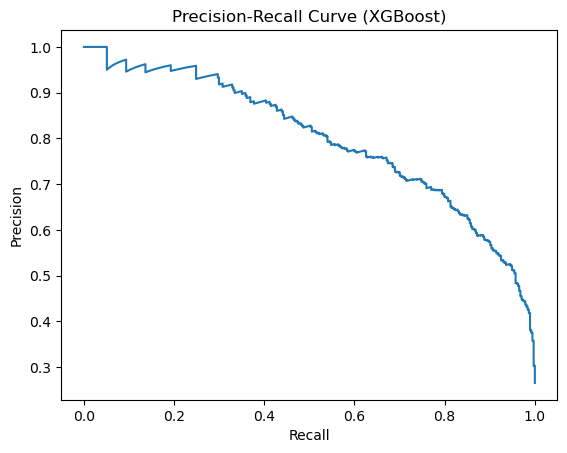

In [101]:
# Visualize trade-off between catching churners and false alarms
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = xgb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.show()
